# Visualize Latents with ActMax

### Imports

In [ ]:
import sys, os 
# sys.path.append(os.path.abspath('.'))

import torch
import torchaudio
import numpy as np
import gin
import rave
import types
# import act_max_util as amu # no PCA
import act_max_pca as amu # with PCA
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F

/Users/DiarmuidFogarty/repos/XRAVE/act_max_pca.py:251: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if Gaussian_Blur and k % theta_every is 0:


### Plotting functions

In [2]:
def plot_mel_spectrogram(mel_spectrogram, title='Mel Spectrogram', dB_scale=True, save_path=None):
    # Remove batch dimension if present
    if mel_spectrogram.dim() == 3 and mel_spectrogram.size(0) == 1:
        mel_spectrogram = mel_spectrogram[0]
    
    if dB_scale:
        mel_spectrogram = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram)
        
    else:
        # Normalize mel spectrogram to [0, 1] range
        mel_min = mel_spectrogram.min()
        mel_max = mel_spectrogram.max()
        if mel_max == mel_min:  # Avoid division by zero
            mel_spectrogram = mel_spectrogram - mel_min
        else:     # Normalize to [0, 1]
            mel_spectrogram = (mel_spectrogram - mel_min) / (mel_max - mel_min)

    plt.figure(figsize=(10, 7))
    plt.imshow(mel_spectrogram, origin="lower", aspect="auto", cmap="magma")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    if dB_scale:
        plt.colorbar(format="%+2.0f dB")
    else:
        plt.colorbar(label="Amplitude")
    if save_path:
        plt.savefig(save_path)
    plt.show()

### Override custom padding in `cached_conv` package

In [3]:
# Not sure of a clean way to do this yet without directly modifying the original package

### Load model

In [ ]:
# Directory containing model checkpoint and config
model_dir = './checkpoints/drumset'

# Load the model
config_path = rave.core.search_for_config(model_dir)
gin.parse_config_file(config_path)
model = rave.RAVE()
run = rave.core.search_for_run(model_dir)
model = model.load_from_checkpoint(run)


print(f'Model loaded from {model_dir}')
print(f'model.latent_size: {model.latent_size}')

model

Model loaded from ./checkpoints/noise_no_padding_phase1_only
model.latent_size: 8
RAVE(
  (pqmf): CachedPQMF(
    (forward_conv): Conv1d(1, 16, kernel_size=(513,), stride=(16,), bias=False)
    (inverse_conv): Conv1d(16, 16, kernel_size=(33,), stride=(1,), bias=False)
  )
  (spectrogram): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (encoder): VariationalEncoder(
    (encoder): EncoderNoPadding(
      (net): Sequential(
        (0): Conv1d(128, 64, kernel_size=(7,), stride=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2)
        (3): Conv1d(64, 128, kernel_size=(5,), stride=(2,))
        (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.2)
        (6): Conv1d(128, 256, kernel_size=(5,), stride=(2,))
        (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_st

RAVE(
  (pqmf): CachedPQMF(
    (forward_conv): Conv1d(1, 16, kernel_size=(513,), stride=(16,), bias=False)
    (inverse_conv): Conv1d(16, 16, kernel_size=(33,), stride=(1,), bias=False)
  )
  (spectrogram): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (encoder): VariationalEncoder(
    (encoder): EncoderV2(
      (net): CachedSequential(
        (0): Conv1d(128, 96, kernel_size=(7,), stride=(1,), bias=False)
        (1): Residual(
          (aligned): Branches(
            (branches): ModuleList(
              (0): DilatedUnit(
                (net): CachedSequential(
                  (0): LeakyReLU(negative_slope=0.2)
                  (1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), bias=False)
                  (2): LeakyReLU(negative_slope=0.2)
                  (3): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
                )
              )
              (1): Identity()
            )
          )
        )
        (2): Leaky

### Initialize input

initial_mel.shape: torch.Size([1, 128, 8])
tensor([[0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
         0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0

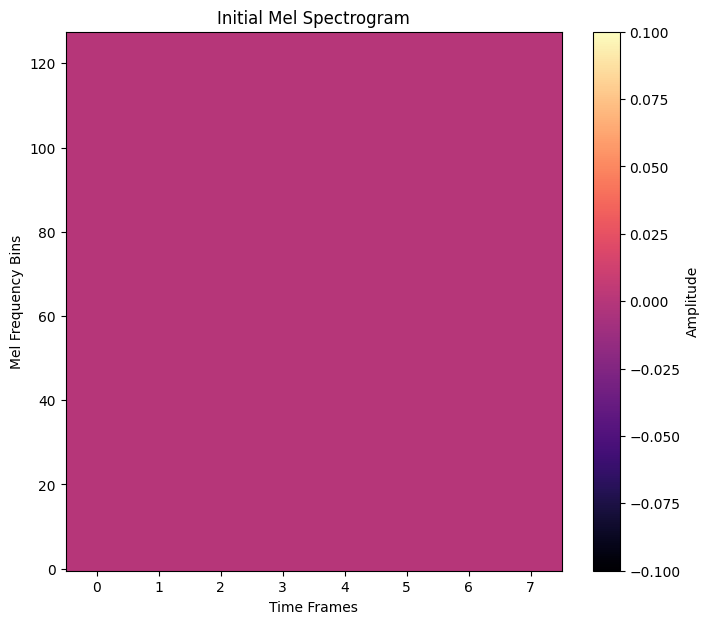

In [5]:
# n_signal = 2048

initial_mel = torch.randn((1, n_mels, C))
print(f'initial_mel.shape: {initial_mel.shape}')
initial_mel[:, :, :] = 10e-3 # NOTE: too small magnitude may lead to negatives in final optimal spectrogram
print(initial_mel[:, :, 0])


plot_mel_spectrogram(input, title='Initial Mel Spectrogram', dB_scale=False)

In [6]:
# noise = torch.randn((1, 2048)) * 1e-3 # small noise to start with
# silence = torch.zeros_like(noise)
# noise_silence = torch.cat([noise, silence], dim=-1)
# print(f'noise_silence.shape: {noise_silence.shape}')
# logmel = torch.log1p(model.spectrogram(noise_silence))
# print(f'logmel.shape: {logmel.shape}')
# print(f'min and max of initial noisy logmel: {logmel.min()}, {logmel.max()}')
# plot_mel_spectrogram(logmel, title='Initial Noisy Mel Spectrogram', dB_scale=False)

### Plot PCA component

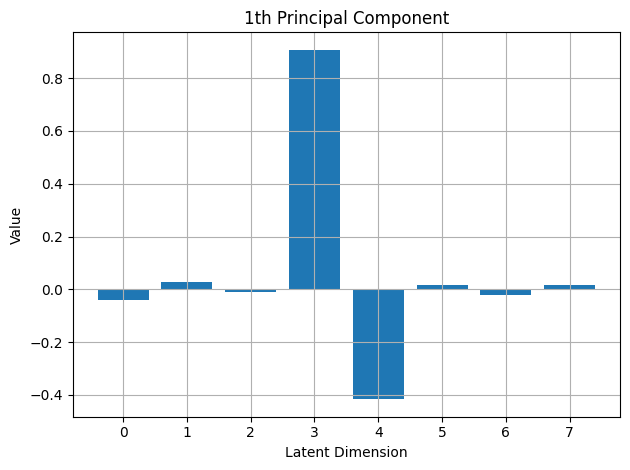

In [7]:
N = 0
pc = model.latent_pca[N]

plt.bar(np.arange(len(pc)), pc)
plt.title(f'{N+1}th Principal Component')
plt.xlabel('Latent Dimension')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### Create hook into final encoder layer

In [8]:
# Create hook into target layer
output_layer_encoder = model.encoder.encoder.net[-1]  # NOTE: (means, scales): (128,128)
layer_name = 'output_layer_encoder'
act_dict = {}
output_layer_encoder.register_forward_hook(amu.layer_hook(act_dict, layer_name))

### Prepare optimization

In [9]:
input = torch.log1p(initial_mel) # log scaling like in RAVE _mel_encode()
input.requires_grad_(True)  # enable gradient computation

# Parameters for activation maximization
steps = 250               # perform 100 iterations
units = range(model.latent_size)     # take all latents
alpha = torch.tensor(0.05)   # learning rate (step size) 
verbose = True              # print activation every step
L2_Decay = False             # enable L2 decay regularizer
Gaussian_Blur = True        # enable Gaussian regularizer
Norm_Crop = False            # enable norm regularizer
Contrib_Crop = False         # enable contribution regularizer
Bin_Avg = False              # [Experimental] enable (some kind of) bin averaging of mel spectrogram

pc = -pc # choose direction of PC to maximize

### Run ActMax

step:  0 activation:  tensor(0.0314, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9653, grad_fn=<DivBackward0>) norm:  tensor(0.1456, grad_fn=<LinalgVectorNormBackward0>)
step:  1 activation:  tensor(0.0326, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9658, grad_fn=<DivBackward0>) norm:  tensor(0.1509, grad_fn=<LinalgVectorNormBackward0>)
step:  2 activation:  tensor(0.0342, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9666, grad_fn=<DivBackward0>) norm:  tensor(0.1580, grad_fn=<LinalgVectorNormBackward0>)
step:  3 activation:  tensor(0.0359, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9673, grad_fn=<DivBackward0>) norm:  tensor(0.1650, grad_fn=<LinalgVectorNormBackward0>)
step:  4 activation:  tensor(0.0375, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9680, grad_fn=<DivBackward0>) norm:  tensor(0.1719, grad_fn=<LinalgVectorNormBackward0>)
step:  5 activation:  tensor(0.0373, grad_fn=<SubBackward0>) cos_sim:  tensor(0.9672, grad_fn=<DivBackward0>) norm:  tensor(0.1719, grad_fn=<LinalgVectorNo

KeyboardInterrupt: 

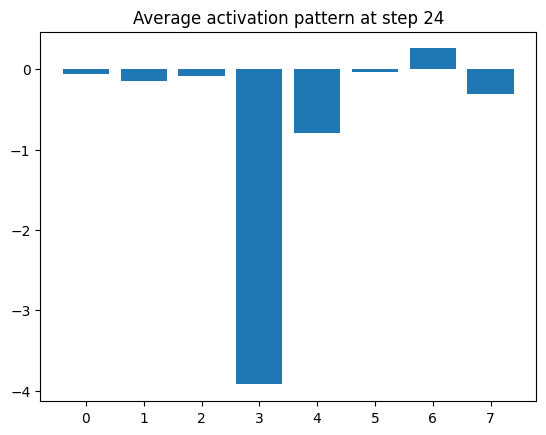

In [10]:
# Run activation maximization
output = amu.act_max(
    network=model,
    input=input,
    layer_activation=act_dict,
    layer_name=layer_name,
    units=units,
    steps=steps,
    alpha=alpha,
    verbose=verbose,
    L2_Decay=L2_Decay,
    Gaussian_Blur=Gaussian_Blur,
    Norm_Crop=Norm_Crop,
    Contrib_Crop=Contrib_Crop,
    update_viz=True,
    theta_width=1,
    theta_every=4,
    pc=pc
)

torch.save(output, './visualisations/optimized_mel.pt')

### Check latent trajectory for concatenated output

In [11]:
output = torch.load('/Users/DiarmuidFogarty/repos/XRAVE/visualisations/optimized_mel.pt')

In [12]:
# # [Experimental] Try setting each entry to the average of the amplitudes across all time frames
# print(f'output.shape before flattening: {output.shape}')
# mel_avg = output.mean(dim=2, keepdim=True)
# mel_flat = mel_avg.expand(-1, -1, output.size(2))
# plot_mel_spectrogram(mel_flat.detach(), title='Flattened Mel', dB_scale=False)
# output = mel_flat

output_concat.shape: torch.Size([1, 128, 80])
Value range: -0.013240580447018147 to 0.0870884358882904


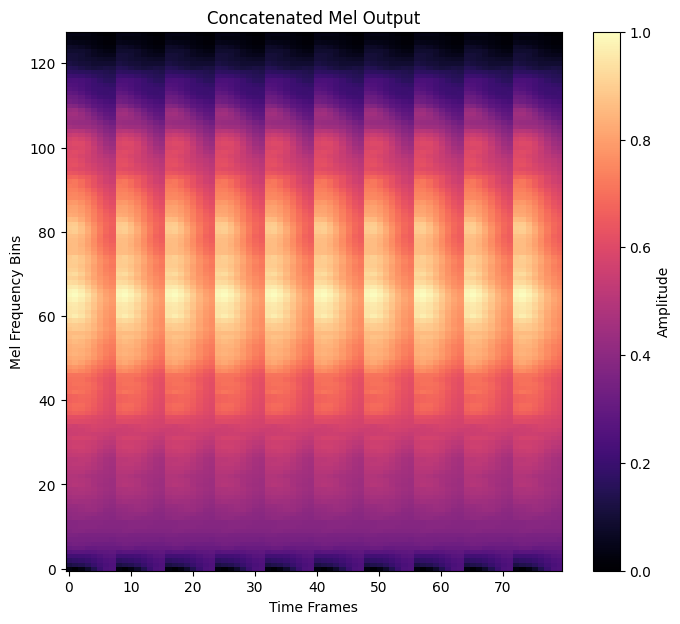

In [13]:
# Concatenate output multiple times to see latent trajectory
n = 10
output_concat = torch.cat([output]*n, dim=-1)
print(f'output_concat.shape: {output_concat.shape}')
print(f'Value range: {torch.min(output_concat)} to {torch.max(output_concat)}')
plot_mel_spectrogram(output_concat.detach(), title='Concatenated Mel Output', dB_scale=False)

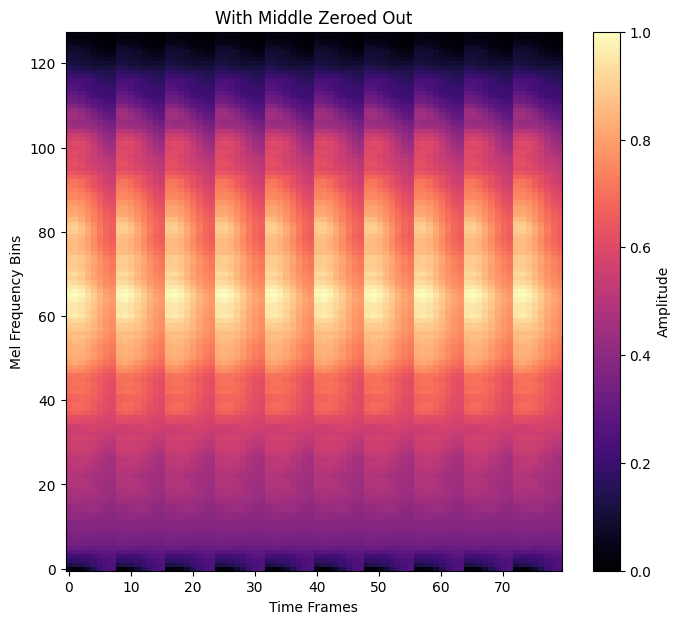

In [ ]:
output_concat[:, :, 80:81] = 0
plot_mel_spectrogram(output_concat.detach(), title='With Middle Zeroed Out', dB_scale=False)

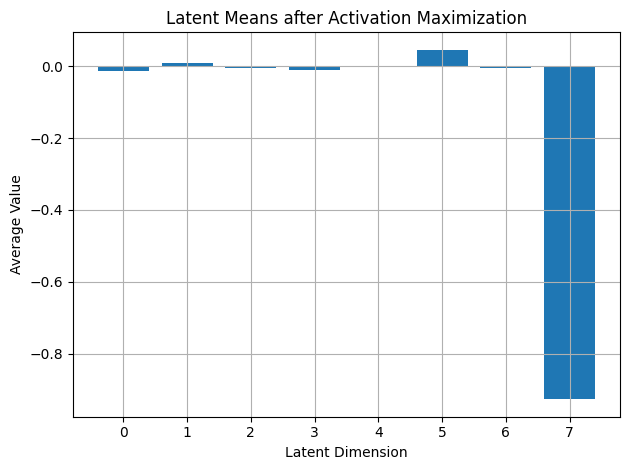

In [15]:
def plot_latent_means(latent_means, title='Latent Means', save_path=None):
    """
    Plots the average value of each latent mean across time frames.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    averages = latent_means.squeeze(0).mean(dim=1).detach()  # Average over time frames
    plt.bar(np.arange(len(averages)), averages)
    plt.title(title)
    plt.xlabel('Latent Dimension')
    plt.ylabel('Average Value')
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()




plot_latent_means(means, title='Latent Means after Activation Maximization')

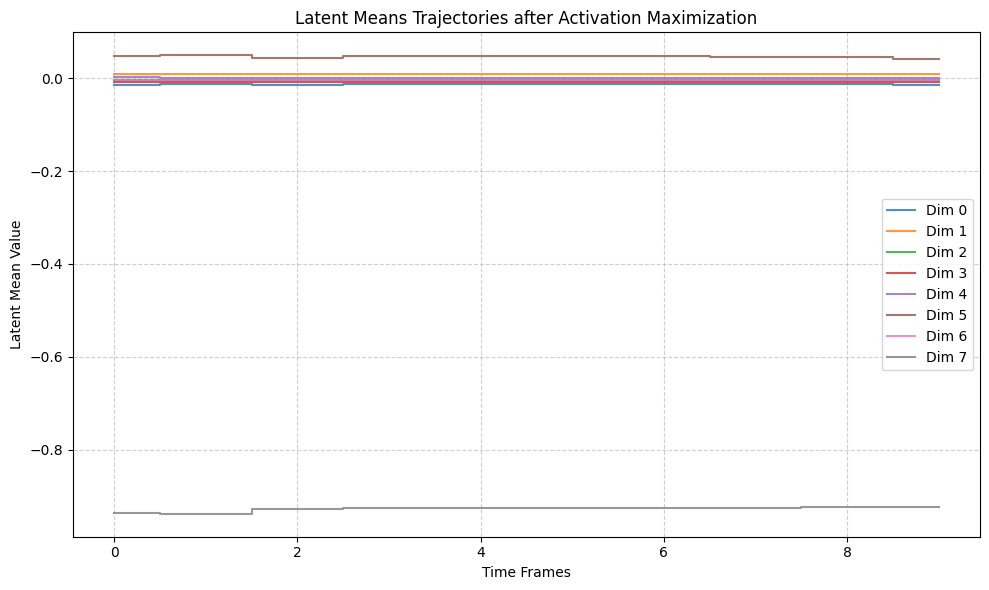

In [16]:
def plot_latent_trajectories(
    latent_means,
    title='Latent Means Trajectories',
    save_path=None
):
    """
    Plots the trajectories of latent means over time using step plots.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    latent_np = latent_means.squeeze(0).cpu().detach().numpy()
    T = latent_np.shape[1]  # number of timesteps

    plt.figure(figsize=(10, 6))
    for dim in range(latent_np.shape[0]):
        plt.step(
            range(T),
            latent_np[dim, :],
            where='mid',
            alpha=0.8,
            label=f'Dim {dim}'
        )

    plt.title(title)
    plt.xlabel('Time Frames')
    plt.ylabel('Latent Mean Value')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    
plot_latent_trajectories(means, title='Latent Means Trajectories after Activation Maximization')

In [17]:
print(means[:, 7, :])

tensor([[-0.9371, -0.9380, -0.9274, -0.9250, -0.9250, -0.9250, -0.9250, -0.9250,
         -0.9223, -0.9237]])


In [18]:
print(means[:, 5, :])

tensor([[0.0489, 0.0494, 0.0439, 0.0469, 0.0469, 0.0469, 0.0469, 0.0466, 0.0461,
         0.0413]])
